In [1]:
pip install numpy pandas matplotlib seaborn scikit-learn

Accuracy: 0.7333333333333333
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        19
           1       0.54      0.54      0.54        13
           2       0.54      0.54      0.54        13

    accuracy                           0.73        45
   macro avg       0.69      0.69      0.69        45
weighted avg       0.73      0.73      0.73        45



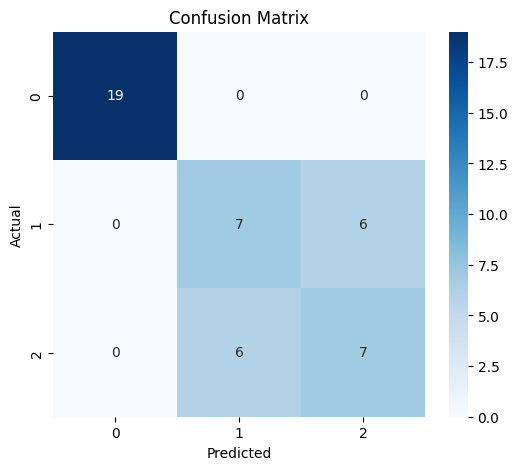

In [2]:
# Import Libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn import datasets
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score

# Load Dataset
iris = datasets.load_iris()

X = iris.data[:, :2]  # use first two features for visualization
y = iris.target

# Train Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

# Feature Scaling
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Train SVM Model
model = SVC(kernel='rbf', C=1, gamma='scale')

model.fit(X_train, y_train)

# Prediction
y_pred = model.predict(X_test)

# Accuracy
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

# Classification Report
print(classification_report(y_test, y_pred))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, cmap="Blues")
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

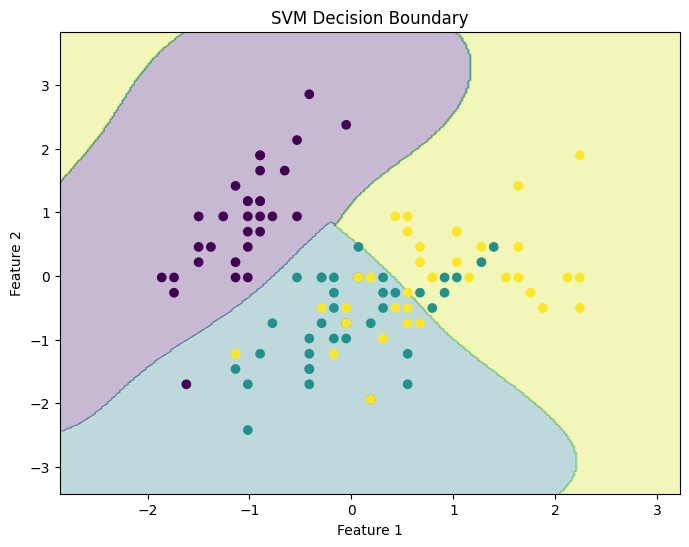

In [3]:
# Decision Boundary Plot

def plot_decision_boundary(X, y, model):

    h = .02

    x_min, x_max = X[:,0].min() - 1, X[:,0].max() + 1
    y_min, y_max = X[:,1].min() - 1, X[:,1].max() + 1

    xx, yy = np.meshgrid(
        np.arange(x_min, x_max, h),
        np.arange(y_min, y_max, h)
    )

    Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)

    plt.figure(figsize=(8,6))
    plt.contourf(xx, yy, Z, alpha=0.3)

    plt.scatter(X[:,0], X[:,1], c=y, cmap="viridis")

    plt.title("SVM Decision Boundary")
    plt.xlabel("Feature 1")
    plt.ylabel("Feature 2")

    plt.show()


plot_decision_boundary(X_train, y_train, model)

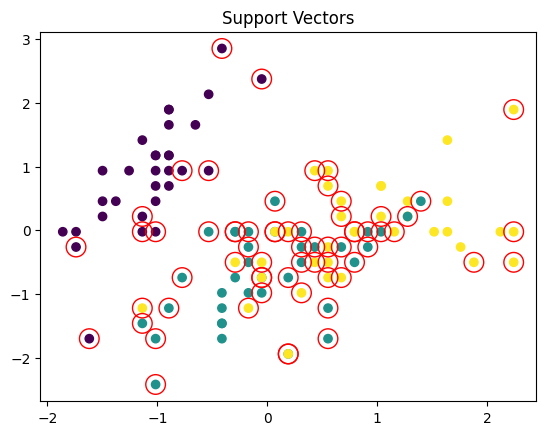

In [4]:
plt.scatter(X_train[:,0], X_train[:,1], c=y_train)

plt.scatter(
    model.support_vectors_[:,0],
    model.support_vectors_[:,1],
    s=200,
    facecolors='none',
    edgecolors='r'
)

plt.title("Support Vectors")
plt.show()

In [5]:
kernels = ['linear', 'poly', 'rbf', 'sigmoid']

for k in kernels:

    svm = SVC(kernel=k)
    svm.fit(X_train, y_train)

    y_pred = svm.predict(X_test)

    print("Kernel:", k)
    print("Accuracy:", accuracy_score(y_test, y_pred))
    print()

Kernel: linear
Accuracy: 0.7333333333333333

Kernel: poly
Accuracy: 0.7555555555555555

Kernel: rbf
Accuracy: 0.7333333333333333

Kernel: sigmoid
Accuracy: 0.7777777777777778

